In [195]:
!pip install grad-cam

In [196]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from PIL import Image
from collections import Counter
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import numpy as np
import torch
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [197]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

torch.backends.cudnn.benchmark = True

In [198]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [199]:
DATA_ROOT = "/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge/Photos"

BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
PATIENCE = 25

CLASS_NAMES = ["Benign", "InSitu", "Invasive", "Normal"]
class_to_idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}

In [200]:
def load_bach():
    samples = []

    for cls in CLASS_NAMES:
        class_dir = os.path.join(DATA_ROOT, cls)

        if not os.path.isdir(class_dir):
            print("Missing:", class_dir)
            continue

        label = class_to_idx[cls]

        files = os.listdir(class_dir)
        print(f"{cls}: {len(files)} files")

        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff")):
                samples.append((os.path.join(class_dir, f), label))

    return samples


In [201]:
class BachDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        try:
            img = Image.open(img_path).convert("RGB")

        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # lấy sample khác thay vì ảnh rỗng
            new_idx = (idx + 1) % len(self.samples)
            return self.__getitem__(new_idx)

        if self.transform:
            img = self.transform(img)

        return img, label

In [202]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((230, 230)),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [203]:
for root, dirs, files in os.walk("/kaggle/input/bach-breast-cancer-histology-images"):
    print(root)

/kaggle/input/bach-breast-cancer-histology-images
/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge_TestDataset
/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge_TestDataset/ICIAR2018_BACH_Challenge_TestDataset
/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge_TestDataset/ICIAR2018_BACH_Challenge_TestDataset/Photos
/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge_TestDataset/ICIAR2018_BACH_Challenge_TestDataset/WSI
/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge_TestDataset/ICIAR2018_BACH_Challenge_TestDataset/WSI/thumbnails
/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge
/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge
/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018_BACH_Challenge/ICIAR2018_BACH_Challenge/Photos
/kaggle/input/bach-breast-cancer-histology-images/ICIAR2018

In [204]:
import os
print(os.listdir(DATA_ROOT))

['InSitu', 'microscopy_ground_truth.csv', 'Benign', 'Normal', 'Invasive']


In [205]:
full_samples = load_bach()

if not full_samples:
    raise ValueError("Không tìm thấy ảnh!")

print("Total samples:", len(full_samples))

Benign: 101 files
InSitu: 101 files
Invasive: 101 files
Normal: 101 files
Total samples: 400


In [206]:
from sklearn.model_selection import train_test_split

# Lấy label list
labels = [s[1] for s in full_samples]

# Nếu có nhiều hơn 1 class thì mới stratify
use_stratify = labels if len(set(labels)) > 1 else None

train_samples, temp_samples = train_test_split(
    full_samples,
    test_size=0.2,
    stratify=use_stratify,
    random_state=42
)

# update lại label cho temp
temp_labels = [s[1] for s in temp_samples]
use_stratify_temp = temp_labels if len(set(temp_labels)) > 1 else None

val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.5,
    stratify=use_stratify_temp,
    random_state=42
)

print("Train:", len(train_samples))
print("Val:", len(val_samples))
print("Test:", len(test_samples))

Train: 320
Val: 40
Test: 40


In [207]:
train_targets = [s[1] for s in train_samples]
class_sample_count = Counter(train_targets)

weights = 1. / torch.tensor(
    [class_sample_count[i] for i in range(len(CLASS_NAMES))],
    dtype=torch.float
)

samples_weights = torch.tensor([weights[t] for t in train_targets])
sampler = WeightedRandomSampler(samples_weights, len(samples_weights))

In [208]:
train_ds = BachDataset(train_samples, train_tf)
val_ds   = BachDataset(val_samples, val_tf)
test_ds  = BachDataset(test_samples, val_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,   # ✅ thay sampler bằng shuffle
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [209]:
def plot_distribution(counts, title):

    labels = CLASS_NAMES
    values = [counts[i] for i in range(len(labels))]

    plt.figure(figsize=(10,4))
    plt.bar(labels, values)
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.show()

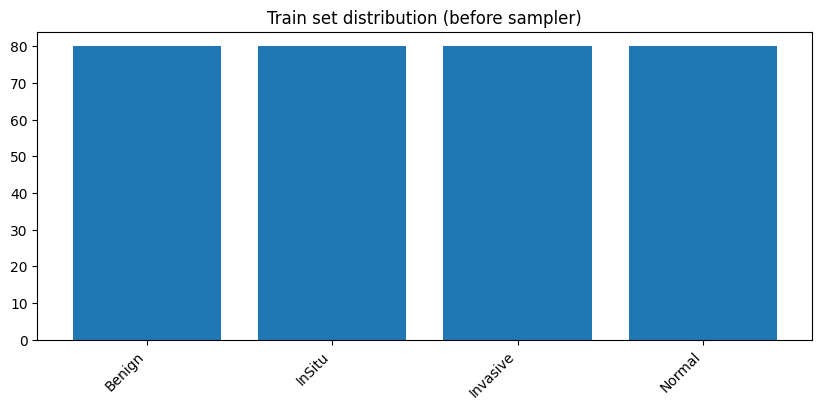

In [210]:
orig_counter = Counter(train_targets)
plot_distribution(orig_counter, "Train set distribution (before sampler)")

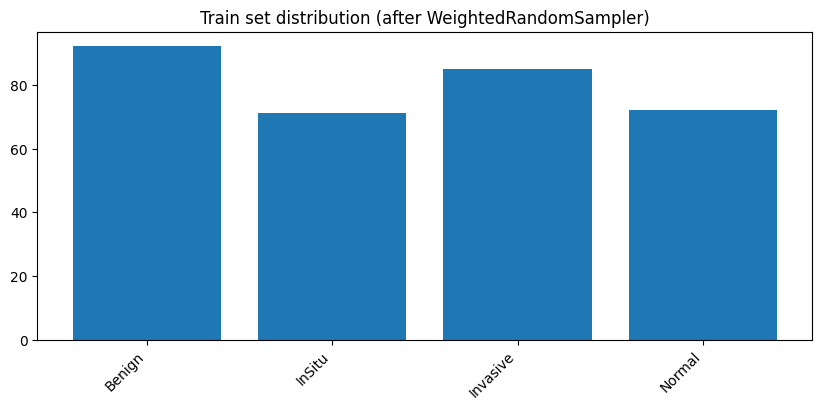

In [211]:
sampled_indices = list(iter(sampler))
sampled_labels = [train_targets[i] for i in sampled_indices]
sampled_counter = Counter(sampled_labels)

plot_distribution(sampled_counter, "Train set distribution (after WeightedRandomSampler)")

In [212]:
class SEBlock(nn.Module):

    def __init__(self, channels, r=16):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // r),
            nn.ReLU(),
            nn.Linear(channels // r, channels),
            nn.Sigmoid()
        )

    def forward(self, x):

        b, c, _, _ = x.size()

        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)

        return x * y


class SelfAttentionClassifier(nn.Module):

    def __init__(self, dim, num_classes):
        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=8,
            batch_first=True
        )

        self.fc = nn.Linear(dim, num_classes)

    def forward(self, x):

        b, c, h, w = x.shape

        x = x.flatten(2).transpose(1,2)

        attn_out,_ = self.attn(x,x,x)

        x = attn_out.mean(dim=1)

        return self.fc(x)


class ConvNeXtAttention(nn.Module):

    def __init__(self):
        super().__init__()

        backbone = convnext_tiny(
            weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )

        self.features = backbone.features

        self.attn = SEBlock(768)
        
        self.classifier = SelfAttentionClassifier(
            dim=768,
            num_classes=len(CLASS_NAMES)   # ✅ sửa ở đây
        )

    def forward(self, x):

        x = self.features(x)

        x = self.attn(x)

        x = self.classifier(x)

        return x

In [213]:
model = ConvNeXtAttention().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-2
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.3
)

In [214]:
def calculate_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    p, r, f, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='macro',
        zero_division=0
    )

    return acc, p, r, f

In [215]:
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

best_f1 = 0.0
best_epoch = 0
best_state = None
best_metrics = None
best_pred = None  
patience_counter = 0

import copy  

print(f"{'Epoch':^6} | {'Train Loss':^10} | {'Val Loss':^9} | {'Val Acc':^9} | {'Val Prec':^9} | {'Val Rec':^9} | {'Val F1':^9} | Status")
print("-" * 110)

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        scheduler.step()

        train_loss += loss.item()

        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()

        train_total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)

    train_acc = train_correct / train_total

    model.eval()

    y_true, y_pred = [], []

    val_loss = 0.0

    with torch.no_grad():

        for imgs, labels in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc, val_prec, val_rec, val_f1 = calculate_metrics(y_true, y_pred)

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    status = ""

    if val_f1 > best_f1:

        best_f1 = val_f1
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        best_metrics = (val_acc, val_prec, val_rec, val_f1)
        best_pred = (y_true.copy(), y_pred.copy())

        patience_counter = 0
        status = "BEST"

    else:

        patience_counter += 1

    print(f"{epoch:^6} | {avg_train_loss:^10.4f} | {val_loss:^9.4f} | "
          f"{val_acc*100:^8.2f}% | {val_prec*100:^8.2f}% | "
          f"{val_rec*100:^8.2f}% | {val_f1*100:^8.2f}% | {status}")

    if patience_counter >= PATIENCE:

        print(f"\nEarly stopping at epoch {epoch}")
        break

Epoch  | Train Loss | Val Loss  |  Val Acc  | Val Prec  |  Val Rec  |  Val F1   | Status
--------------------------------------------------------------------------------------------------------------


  1    |   1.3835   |  1.3777   |  25.00  % |  12.28  % |  25.00  % |  16.46  % | BEST


  2    |   1.3772   |  1.3714   |  25.00  % |  12.12  % |  25.00  % |  16.29  % | 


  3    |   1.3710   |  1.3629   |  37.50  % |  55.19  % |  37.50  % |  31.62  % | BEST


  4    |   1.3621   |  1.3493   |  55.00  % |  65.59  % |  55.00  % |  53.72  % | BEST


...

  49   |   0.2070   |  0.4505   |  85.00  % |  88.46  % |  85.00  % |  84.45  % | 


  50   |   0.2106   |  0.4045   |  87.50  % |  89.18  % |  87.50  % |  87.19  % | 


  51   |   0.2091   |  0.5893   |  75.00  % |  83.48  % |  75.00  % |  72.19  % | 


  52   |   0.2066   |  0.4854   |  82.50  % |  85.91  % |  82.50  % |  81.28  % | 


  53   |   0.2057   |  0.4333   |  85.00  % |  87.29  % |  85.00  % |  84.27  % | 

Early stopping at epoch 53


In [216]:
model.load_state_dict(best_state)
model.eval()

y_true_test, y_pred_test = [], []

with torch.no_grad():
    for imgs, labels in test_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        y_true_test.extend(labels.cpu().numpy())
        y_pred_test.extend(preds.cpu().numpy())

In [217]:
test_acc, test_prec, test_rec, test_f1 = calculate_metrics(
    y_true_test, y_pred_test
)

In [218]:
print("\nFINAL TEST RESULT")
print(f" Accuracy  : {test_acc*100:.2f}%")
print(f" Precision : {test_prec*100:.2f}%")
print(f" Recall    : {test_rec*100:.2f}%")
print(f" F1-score  : {test_f1*100:.2f}%")


FINAL TEST RESULT
 Accuracy  : 87.50%
 Precision : 89.02%
 Recall    : 87.50%
 F1-score  : 86.72%


In [219]:
y_true, y_pred = best_pred
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.80      0.89        10
      InSitu       1.00      0.90      0.95        10
    Invasive       0.83      1.00      0.91        10
      Normal       0.82      0.90      0.86        10

    accuracy                           0.90        40
   macro avg       0.91      0.90      0.90        40
weighted avg       0.91      0.90      0.90        40



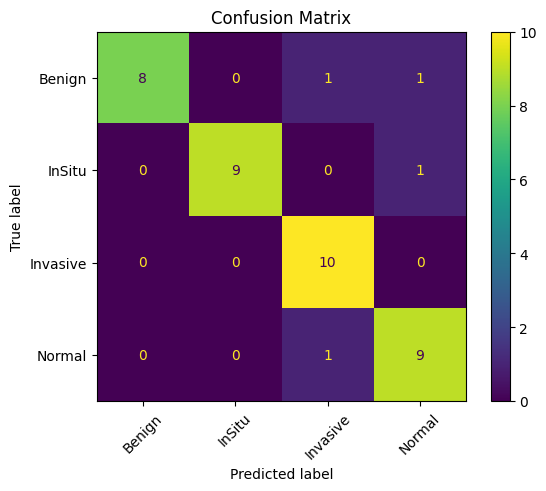

In [220]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

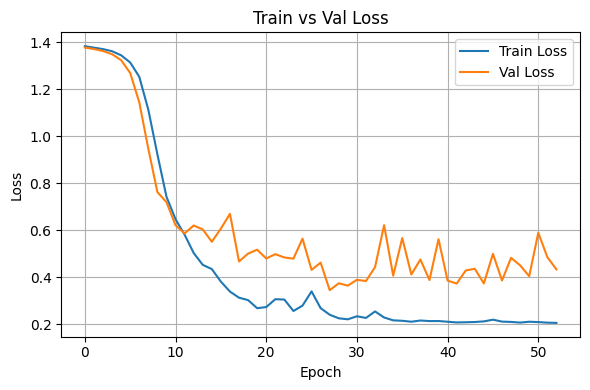

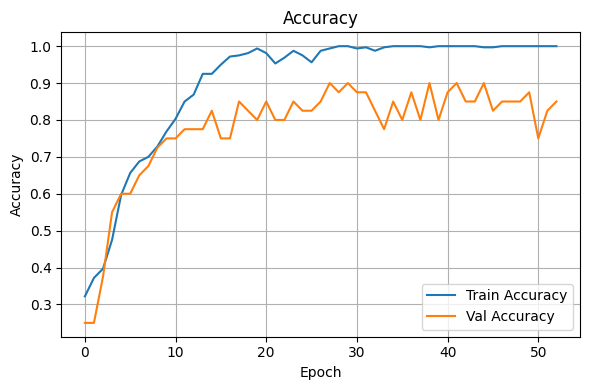

In [221]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Train vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [222]:
features, gradients = [], []

def forward_hook(module, input, output):
    features.clear()
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.clear()
    gradients.append(grad_output[0])

target_layer = model.features[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

def grad_cam_single(img, class_idx):
    model.eval()
    img = img.unsqueeze(0).to(device)

    features.clear()
    gradients.clear()

    out = model(img)
    model.zero_grad()

    out[0, class_idx].backward()

    fmap = features[0]
    grad = gradients[0]

    weights = grad.mean(dim=(2,3), keepdim=True)
    cam = (weights * fmap).sum(dim=1).squeeze()

    cam = cam.detach().cpu().numpy()
    cam = np.maximum(cam, 0)

    if cam.max() != 0:
        cam = cam / cam.max()

    return cam

def grad_cam_all_classes(img):
    cams = []
    for class_idx in range(len(CLASS_NAMES)):
        cam = grad_cam_single(img, class_idx)
        cam = cv2.resize(cam, (224,224))
        cams.append(cam)
    return cams

In [ ]:
from sklearn.metrics import f1_score

# lấy kết quả tốt nhất từ training
y_true, y_pred = best_pred

# tính F1 từng class
f1_per_class = f1_score(y_true, y_pred, average=None)

# chọn class tốt nhất
best_class_idx = np.argmax(f1_per_class)

print("Best class:", CLASS_NAMES[best_class_idx])

Best class: InSitu


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


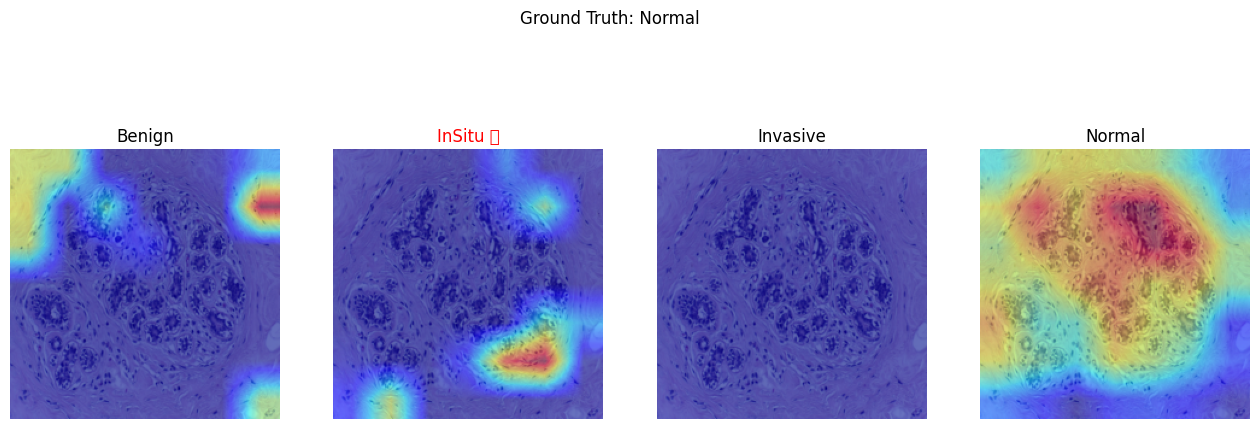

In [ ]:
img, label = test_ds[0]
cams = grad_cam_all_classes(img)

img_np = img.permute(1,2,0).numpy()
img_np = (img_np - img_np.min())/(img_np.max()-img_np.min())

plt.figure(figsize=(16,10))
for i, cam in enumerate(cams):
    plt.subplot(2,4,i+1)
    plt.imshow(img_np)
    plt.imshow(cam, cmap='jet', alpha=0.5)

    if i == best_class_idx:
        plt.title(f"{CLASS_NAMES[i]} ⭐", color='red')
    else:
        plt.title(CLASS_NAMES[i])

    plt.axis('off')

plt.suptitle(f"Ground Truth: {CLASS_NAMES[label]}")
plt.show()